In [1]:
make_live = True
email_both = False
send_email = True

In [2]:
from pydataquery import DataQuery
import pandas as pd
from xbbg import blp
import numpy as np
import pytz
import time
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact, Dropdown, HBox, VBox, Button, Output, Text, widgets
from IPython.display import display, clear_output
import sympy as sp
from sklearn.metrics import r2_score
from scipy.stats import zscore
import re
import scipy.stats as stats
import matplotlib.pyplot as plt
import itertools
import warnings
import pyautogui
import pythoncom
import subprocess
import pygetwindow as gw
import time
warnings.filterwarnings("ignore")

if make_live:

    dq = DataQuery(
        client_id='jbAIMF2Tkp0JO3sc',
        client_secret='d7qfzgt55pddjs352sgxosFyI4t2eja07k7opbi6wg9oqjc1OjkdAksn1btmnugeMjchcx2vwTsJupw',
        # calendar = 'CAL_USBANK',
    )
    
    labels = { "CDX Options | IG Main | Standard |  | On the Run (5y) | 3 month | ATM Implied Volatility":"DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,3M_ATM_IVOL_CAL)", "CDX Options | IG Main | Standard |  | On the Run (5y) | 3 month | Realized Volatility":"DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,3M_HVOL)", "CDX Options | IG Main | Standard |  | On the Run (5y) | 3 month | Volatility Skew (75-25 Delta)":"DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,3M_VOL_SKEW_CAL)", "CDX Options | HY Main | Standard |  | On the Run (5y) | 3 month | ATM Implied Volatility":"DB(CDS,TRAC-X,NAHY100UNF05ONRUN,3M_ATM_S_IVOL_CAL)", "CDX Options | HY Main | Standard |  | On the Run (5y) | 3 month | Realized Volatility":"DB(CDS,TRAC-X,NAHY100UNF05ONRUN,3M_S_HVOL)", "CDX Options | HY Main | Standard |  | On the Run (5y) | 3 month | Volatility Skew (75-25 Delta)":"DB(CDS,TRAC-X,NAHY100UNF05ONRUN,3M_S_VOL_SKEW_CAL)", "iTraxx Options (% of ATM) | Main | 100% | 3 month | Implied Vol":"DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_C100P_3M_INTERP,JPM_ATMVOL)", "iTraxx Options (% of ATM) | Main | 100% | 3 month | Realised Vol":"STDDEV(21 * 3,DB(NEO-UK,CREDRESEARCH/EU/EUROPEEUR05ONRUN/JPM_LOG_SPR_RET))*SQRT(252)/100", "iTraxx Options (% of ATM) | Main | 100% | 3 month | Volatility Skew (25 Delta)":"DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)-DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_C25D_3M_INTERP,JPM_VOL)", "iTraxx Options (% of ATM) | Crossover | 100% | 3 month | Implied Vol":"DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_C100P_3M_INTERP,JPM_ATMVOL)", "iTraxx Options (% of ATM) | Crossover | 100% | 3 month | Realised Vol":"STDDEV(21 * 3,DB(NEO-UK,CREDRESEARCH/EU/EUROPEHY05ONRUN/JPM_LOG_SPR_RET))*SQRT(252)/100", "iTraxx Options (% of ATM) | Crossover | 100% | 3 month | Volatility Skew (25 Delta)":"DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)-DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_C25D_3M_INTERP,JPM_VOL)", "iTraxx Options (% of ATM) | Senior Financial | 100% | 3 month | Implied Vol":"DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_C100P_3M_INTERP,JPM_ATMVOL)", "iTraxx Options (% of ATM) | Senior Financial | 100% | 3 month | Realised Vol":"STDDEV(21 * 3,DB(NEO-UK,CREDRESEARCH/EU/EUROPESEN05ONRUN/JPM_LOG_SPR_RET))*SQRT(252)/100", "iTraxx Options (% of ATM) | Senior Financial | 100% | 3 month | Volatility Skew (25 Delta)":"DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)-DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_C25D_3M_INTERP,JPM_VOL)", "iTraxx Options (% of ATM) | Sub Financial | 100% | 3 month | Implied Vol":"DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_C100P_3M_INTERP,JPM_ATMVOL)", "iTraxx Options (% of ATM) | Sub Financial | 100% | 3 month | Realised Vol":"STDDEV(21 * 3,DB(NEO-UK,CREDRESEARCH/EU/EUROPESUB05ONRUN/JPM_LOG_SPR_RET))*SQRT(252)/100", "iTraxx Options (% of ATM) | Sub Financial | 100% | 3 month | Volatility Skew (25 Delta)":"DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)-DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_C25D_3M_INTERP,JPM_VOL)",}
             
    new_labels = {}
    for key, val in labels.items():
        if "CDX" in key.split(" | ")[0]:
            new_key = (f"{key.split(" | ")[1]}_{key.split(" | ")[5]}_{key.split(" | ")[6]}")
        if "iTraxx" in key.split(" | ")[0]:
            new_key = (f"{key.split(" | ")[1]}_{key.split(" | ")[3]}_{key.split(" | ")[4]}")
        new_key = new_key.replace("IG Main","CDX IG 5Y").replace("HY Main","CDX HY 5Y").\
            replace("Main","ITRX Main 5Y").replace("Crossover","ITRX Xover 5Y").replace("Senior Financial","ITRX SNRFIN 5Y").\
            replace("Sub Financial","ITRX SUBFIN 5Y").replace("3 month","3M").replace("ATM Implied Volatility","iVol").\
            replace("Realized Volatility","rVol")#.replace("Volatility Skew (75-25 Delta)","Vol
        if new_key[-4:] == 'rVol' or 'Realised' in new_key:
            new_labels[new_key] = val
    
    labels = {"CDX Options | IG Main | Delta based Strikes | 25% | On the Run (5y) | 3 month | Implied Volatility" : "DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,25D_3M_IVOL)", "CDX Options | IG Main | Delta based Strikes | 50% | On the Run (5y) | 3 month | Implied Volatility" : "DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,50D_3M_IVOL)", "CDX Options | HY Main | Delta based Strikes | 25% | On the Run (5y) | 3 month | Implied Volatility" : "DB(CDS,TRAC-X,NAHY100UNF05ONRUN,25D_3M_IVOL)", "CDX Options | HY Main | Delta based Strikes | 50% | On the Run (5y) | 3 month | Implied Volatility" : "DB(CDS,TRAC-X,NAHY100UNF05ONRUN,50D_3M_IVOL)", "iTraxx Options (Delta) | Main | 25% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Main | 50% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_P50D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Crossover | 25% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Crossover | 50% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_P50D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Senior Financial | 25% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Senior Financial | 50% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_P50D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Sub Financial | 25% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_P25D_3M_INTERP,JPM_VOL)", "iTraxx Options (Delta) | Sub Financial | 50% | 3 month | Implied Vol" : "DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_P50D_3M_INTERP,JPM_VOL)"}
    for key, val in labels.items():
        if "CDX" in key.split(" | ")[0]:
            new_key = (f"{key.split(" | ")[1]}_{key.split(" | ")[3]}_{key.split(" | ")[5]}_{key.split(" | ")[6]}")
        if "iTraxx" in key.split(" | ")[0]:
            new_key = (f"{key.split(" | ")[1]}_{key.split(" | ")[2]}_{key.split(" | ")[3]}_{key.split(" | ")[4]}")
        new_key = new_key.replace("IG Main","CDX IG 5Y").replace("HY Main","CDX HY 5Y").\
            replace("Main","ITRX Main 5Y").replace("Crossover","ITRX Xover 5Y").replace("Senior Financial","ITRX SNRFIN 5Y").\
            replace("Sub Financial","ITRX SUBFIN 5Y").replace("3 month","3M").replace("Implied Volatility","iVol").\
            replace("Implied Vol","iVol")
        new_labels[new_key] = val
        if '_25%_' in new_key or '_50%_' in new_key:
            new_labels[new_key.replace('3M','1M')] = val.replace('_3M_','_1M_')
    
    # labels = {"CDX IG 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,1M_ATM_IVOL_CAL)", "CDX IG 5Y_1M_rVol" : "DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,1M_HVOL)", "CDX HY 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,NAHY100UNF05ONRUN,1M_ATM_S_IVOL_CAL)", "CDX HY 5Y_1M_rVol" : "DB(CDS,TRAC-X,NAHY100UNF05ONRUN,1M_S_HVOL)", "ITRX Main 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX Main 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPEEUR05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100", "ITRX Xover 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX Xover 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPEHY05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100", "ITRX SNRFIN 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX SNRFIN 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPESEN05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100", "ITRX SUBFIN 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX SUBFIN 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPESUB05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100"}
    l1 = {}
    labels = {"CDX IG 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,1M_ATM_IVOL_CAL)", "CDX IG 5Y_1M_rVol" : "DB(CDS,TRAC-X,NAIGMAINSWAP05YONRUN,1M_HVOL)", "CDX HY 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,NAHY100UNF05ONRUN,1M_ATM_S_IVOL_CAL)", "CDX HY 5Y_1M_rVol" : "DB(CDS,TRAC-X,NAHY100UNF05ONRUN,1M_S_HVOL)", "ITRX Main 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPEEURUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX Main 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPEEUR05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100", "ITRX Xover 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPEHYUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX Xover 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPEHY05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100", "ITRX SNRFIN 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPESENUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX SNRFIN 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPESEN05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100", "ITRX SUBFIN 5Y_50D_1M_iVol" : "DB(CDS,TRAC-X,EUROPESUBUNF05ONRUN_NEW_C50D_1M_INTERP,JPM_VOL)", "ITRX SUBFIN 5Y_1M_rVol" : "STDDEV(21,DB(CDS,TRAC-X,EUROPESUB05ONRUN,JPM_LOG_SPR_RET))*SQRT(252)/100"}
    for key, val in labels.items():
        if key.rsplit('_',1)[1] == 'rVol':
            l1[key] = val
    labels = l1

    labels = {**labels, **new_labels}
    
    job = dq.create_job(expressions = list(labels.values()))
    dq.start_date = 'TODAY-10Y'
    job.execute()
    df = job.to_dataframe()
    df = job.to_pivot_table()
    df = df.T
    df = df[list(labels.values())]
    df.index.name = 'Date'
    df.index = pd.to_datetime(df.index, format='%Y%m%d').date
    
    df.rename(columns={v:k for k, v in labels.items()},inplace=True)
    df.columns.name = None
    clear_output(wait=False)
    df.index = pd.to_datetime(df.index)
    df.to_parquet("DQ Option Data.parquet")
else:
    df = pd.read_parquet("DQ Option Data.parquet")

In [3]:
if make_live:
    file_path = r"J:\\All Data\\56. Vol Daily Emails\\Equity Index Data v3.xlsx"
    window_title = "Equity Index Data v3- Excel"
    
    subprocess.Popen(['start', 'excel', file_path], shell=True)
    time.sleep(10)
    
    excel_windows = [window for window in gw.getWindowsWithTitle('Excel')]
    
    for window in excel_windows:
        if window_title in window.title:
            window.activate()
            break
    
    time.sleep(5)
    pyautogui.hotkey('ctrl', 's')
    time.sleep(5)
    pyautogui.hotkey('alt', 'f4')
    time.sleep(2)
    pyautogui.hotkey('enter')
    time.sleep(5)

In [4]:
df = pd.read_parquet("DQ Option Data.parquet")
df.index = pd.to_datetime(df.index)

for sheet in ['1M','3M']:    
    df2 = pd.read_excel("Equity Index Data v3.xlsx", sheet_name = sheet, parse_dates=True).iloc[2:,:]
    
    all_df = None
    for i in range(len(df2.columns))[::2]:
        current_df = df2.iloc[:,[i,i+1]]
        current_df.columns = ["Date",current_df.columns[1]]
        current_df = current_df.set_index("Date")
        current_df = current_df[~pd.isna(current_df.index)]
        all_df = pd.concat([all_df,current_df],axis=1)    
    
    new_col = []
    for item in all_df.columns:
        if len(item.split("_"))==4:
            new_col += [item.split("_")[0] + "_" + item.split("_")[2] + "_" + item.split("_")[1] + "_" + item.split("_")[3]]
        else:
            new_col += [item]
    all_df.columns = new_col
    
    for item in all_df.columns:
        test = all_df[[item]].dropna().copy()
        if len(test[test[item]<1]) > 1:
            all_df[item] *=100
    
    df = pd.concat([df, all_df],axis=1).sort_index().copy()
df.columns = df.columns.str.replace("Implied Vol","iVol").str.replace("Realised Vol","rVol").str.\
    replace("IV","iVol").str.replace("%","D")
df = df[[col for col in df.columns if not "Skew" in col]].copy()
df = df[df.index.dayofweek<5].copy()

In [5]:
etfs = ["HYG US Equity","LQD US Equity","EMB US Equity","VCIT US Equity",
        "IHYG LN Equity","IEAC LN Equity", "TLT US Equity"]
bbg = blp.bdh(tickers=etfs, flds="YAS_ISPREAD_TO_GOVT",start_date=datetime.now()-timedelta(days=5*365))
bbg.columns = [item.split(" ")[0] + " G-Sprd" for item in etfs]
bbg.index = pd.to_datetime(bbg.index)
bg = bbg.copy()

etfs = ["SPX Index","SX5E Index","RTY Index"]
bbg = blp.bdh(tickers=etfs, flds="PX_LAST",start_date=datetime.now()-timedelta(days=5*365))
bbg.columns = [item.split(" ")[0] + " Price" for item in etfs]
bbg.index = pd.to_datetime(bbg.index)
bg = pd.concat([bg, bbg], axis=1)
bbg = bg.copy()

In [6]:
names = list(sorted(set([item.split("_")[0] for item in df.columns])))
names.remove("EMB")
all_df1 = pd.DataFrame(index=df.index)
for col in bbg.columns:
    all_df1[col] = bbg[col]

for item in names:     
    df1 = pd.DataFrame(index=df.index)
    df1[f"{item} 3M iVol"] = df[f"{item}_50D_3M_iVol"]
    df1[f"{item} 3M rVol"] = df[f"{item}_3M_rVol"]
    df1[f"{item} 3M iVol/rVol"] = df[f"{item}_50D_3M_iVol"] / df[f"{item}_3M_rVol"]
    df1[f"{item} 3M iVol/rVol (10 SMA)"] = df1[f"{item} 3M iVol/rVol"].rolling(10,min_periods=8).mean()
    df1[f"{item} 3M 25-50% pay delta skew"] = df[f"{item}_25D_3M_iVol"] - df[f"{item}_50D_3M_iVol"]
    df1[f"{item} 3M 25-50% pay delta skew (10 SMA)"] = df1[f"{item} 3M 25-50% pay delta skew"].rolling(10,min_periods=8).mean()
    df1[f"{item} 3M 25-50% pay delta skew (normalized; 10 SMA)"] = ((df[f"{item}_25D_3M_iVol"] -\
                                     df[f"{item}_50D_3M_iVol"]) / df[f"{item}_50D_3M_iVol"]).rolling(10,min_periods=8).mean()

    df1[f"{item} 1M iVol"] = df[f"{item}_50D_1M_iVol"]
    df1[f"{item} 1M rVol"] = df[f"{item}_1M_rVol"]
    df1[f"{item} 1M iVol/rVol"] = df[f"{item}_50D_1M_iVol"] / df[f"{item}_1M_rVol"]
    df1[f"{item} 1M 25-50% pay delta skew"] = df[f"{item}_25D_1M_iVol"] - df[f"{item}_50D_1M_iVol"]

    # df1 = df1.dropna().copy()
    all_df1 = pd.concat([all_df1, df1],axis=1)

df1 = all_df1.copy()

ValueError: Cannot set a DataFrame with multiple columns to the single column CDX HY 5Y 1M iVol

In [7]:
df

,CDX IG 5Y_50D_1M_iVol,CDX IG 5Y_50D_1M_iVol,CDX IG 5Y_1M_rVol,CDX HY 5Y_50D_1M_iVol,CDX HY 5Y_50D_1M_iVol,CDX HY 5Y_1M_rVol,ITRX Main 5Y_50D_1M_iVol,ITRX Main 5Y_50D_1M_iVol,ITRX Main 5Y_1M_rVol,ITRX Xover 5Y_50D_1M_iVol,...,IEAC_3M_rVol,IHYG_50D_3M_iVol,IHYG_25D_3M_iVol,IHYG_3M_rVol,TLT_50D_3M_iVol,TLT_25D_3M_iVol,TLT_3M_rVol,RTY_50D_3M_iVol,RTY_25D_3M_iVol,RTY_3M_rVol
2015-10-14,0.461412,0.468975,0.385024,0.437368,0.444026,0.339919,0.517622,0.517620,0.532059,0.593440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-15,0.434332,0.437078,0.389255,0.412346,0.416141,0.351713,0.497051,0.497049,0.525681,0.546461,...,3.169472,NaN,NaN,5.839107,14.463,14.65763,14.197196,18.46569,21.96981,20.45869
2015-10-16,0.434055,0.437900,0.409912,0.415096,0.414395,0.351699,0.505435,0.505433,0.522355,0.551629,...,3.169277,NaN,NaN,5.812216,14.3525,14.54731,14.148079,18.83113,22.47413,20.400995
2015-10-19,0.425401,0.421624,0.409571,0.406245,0.396065,0.360739,0.511831,0.511828,0.523336,0.559277,...,3.095033,NaN,NaN,5.830854,14.457,14.67381,14.21597,18.406,22.04369,20.542258
2015-10-20,0.436200,0.445059,0.409287,0.414080,0.417779,0.360679,0.502824,0.502822,0.523355,0.551039,...,3.092947,NaN,NaN,5.785251,14.36231,14.6015,14.171329,18.56569,22.15738,20.381186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-09,0.409478,0.414386,0.189340,0.312898,0.317476,0.169617,0.414895,0.414893,0.189266,0.406898,...,2.186703,4.8836,8.4787,2.142148,12.9691,13.4606,10.196994,20.9128,23.2364,17.422066
2025-10-10,0.484797,0.494006,0.248568,0.404479,0.410160,0.231143,0.484793,0.484790,0.195639,0.472531,...,2.163692,5.8273,9.2039,2.239787,13.3431,13.7359,10.647582,23.0192,25.9909,18.48032
2025-10-13,NaN,NaN,NaN,NaN,NaN,NaN,0.466303,0.466300,0.198319,0.463694,...,2.172516,5.3775,9.6286,2.282101,12.9379,13.2483,10.305169,21.4115,24.492,19.144765
2025-10-14,0.459185,0.477970,0.256072,0.372930,0.388741,0.233519,0.478848,0.478845,0.200950,0.470367,...,2.1848,5.2306,9.1043,2.265574,13.1038,13.3309,10.232925,22.3528,25.2973,19.148894


In [ ]:
from collections.abc import Iterable
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

names_list = [["HYG", "CDX HY 5Y"], ["LQD", "TLT","CDX IG 5Y"], ["ITRX Main 5Y", 'ITRX Xover 5Y'],
              ["SPX","RTY"], ["SPX","CDX HY 5Y"], ["SX5E","ITRX Xover 5Y"], ["IHYG","ITRX Xover 5Y"],
              ['ITRX SNRFIN 5Y', "ITRX Main 5Y","IEAC"]]

def _ensure_iterable(x):
    if isinstance(x, str) or not isinstance(x, Iterable):
        return [x]
    return list(x)

def _last_val(df, col):
    if col not in df.columns:
        return float('nan')
    s = df[col].dropna()
    return round(s.iloc[-1], 2) if not s.empty else float('nan')

plot_num = 0

for group in names_list:
    items = _ensure_iterable(group)

    fig1, axs1 = plt.subplots(1, 2, figsize=(14, 4))
    fig2, axs2 = plt.subplots(1, 2, figsize=(14, 4))

    ax_left = axs2[0]
    ax_right = None

    for idx, item in enumerate(items):
        col_ivol           = f"{item} 3M iVol"
        col_rvol           = f"{item} 3M rVol"
        col_ratio_10       = f"{item} 3M iVol/rVol (10 SMA)"
        col_ratio          = f"{item} 3M iVol/rVol"
        col_skew_norm_10   = f"{item} 3M 25-50% pay delta skew (normalized; 10 SMA)"
        col_skew_10        = f"{item} 3M 25-50% pay delta skew (10 SMA)"

        last_ivol              = _last_val(df1, col_ivol)
        last_rvol              = _last_val(df1, col_rvol)
        last_10sma_vol_ratio   = _last_val(df1, col_ratio_10)
        last_vol_ratio         = _last_val(df1, col_ratio)
        last_10sma_skew_norm   = _last_val(df1, col_skew_norm_10)
        last_10sma_skew        = _last_val(df1, col_skew_10)

        if col_ratio_10 in df1.columns:
            title = f"{item} ({last_ivol}) / ({last_rvol}): {last_10sma_vol_ratio}"
            df1[col_ratio_10].dropna().plot(ax=axs1[1], label=title)

        if col_ratio in df1.columns:
            cutoff = datetime.now() - timedelta(days=6*30)
            x = df1.loc[df1.index > cutoff, col_ratio].dropna()
            if not x.empty:
                title2 = f"{item} ({last_ivol}) / ({last_rvol}): {last_vol_ratio}"
                x.plot(ax=axs1[0], label=title2)

        if col_skew_norm_10 in df1.columns:
            title3 = f"{item}: {last_10sma_skew_norm}"
            df1[col_skew_norm_10].dropna().plot(ax=axs2[1], label=title3)

        if col_skew_10 in df1.columns:
            use_secondary = (idx == len(items) - 1)

            if use_secondary:
                val = " (right)"
                if ax_right is None:
                    ax_right = ax_left.twinx()

                target_ax = ax_right
                line_color = 'green'
            else:
                val = ""
                target_ax = ax_left
                line_color = None

            title4 = f"{item}{val}: {last_10sma_skew}"
            df1[col_skew_10].dropna().plot(
                ax=target_ax,
                label=title4,
                color=line_color
            )

    axs1[0].axhline(1, color="orange", linestyle="--")
    axs1[1].axhline(1, color="orange", linestyle="--")
    axs1[0].legend(loc="upper left")
    axs1[1].legend(loc="upper left")
    axs1[0].set_title("3M iVol() / rVol()")
    axs1[1].set_title("3M iVol() / rVol() (10 SMA)")

    axs2[0].set_title("3M 25-50% Pay Delta Skew (10 SMA)")
    axs2[1].set_title("3M 25-50% Pay Delta Skew (normalized; 10 SMA)")

    handles_l, labels_l = axs2[0].get_legend_handles_labels()
    if ax_right is not None:
        handles_r, labels_r = ax_right.get_legend_handles_labels()
        axs2[0].legend(handles_l + handles_r, labels_l + labels_r, loc="upper left")
    else:
        axs2[0].legend(loc="upper left")

    fig1.tight_layout()
    fig2.tight_layout()

    fig1.savefig(f"Plots/VolPremium_{plot_num}.png", dpi=150)
    fig2.savefig(f"Plots/VolSkew_{plot_num}.png", dpi=150)

    plot_num += 1

    fig1.show()
    fig2.show()

In [ ]:
def plot_funct(x_scatter, y_scatter):
    valid_mask = (~x_scatter.isna()) & (~y_scatter.isna())
    x_scatter = x_scatter[valid_mask]
    y_scatter = y_scatter[valid_mask]
    coeffs = np.polyfit(x_scatter, y_scatter, 2)
    polynomial = np.poly1d(coeffs)
    x_poly=np.linspace(min(x_scatter),max(x_scatter),500)
    y_poly=polynomial(x_poly)
    y_pred = polynomial(x_scatter)
    r2=r2_score(y_scatter,y_pred)
    equation_text = f"y = {coeffs[0]:.4f}*x² + {coeffs[1]:.4f}*x + {coeffs[2]:.4f}"
    residuals = y_scatter-y_pred
    res_sum = np.sum(residuals**2)
    dof = len(x_scatter)-len(coeffs)
    res_var = res_sum / dof
    se = np.sqrt(res_var)
    conf_upper = y_poly + 2 * se
    conf_lower = y_poly - 2 * se
    return x_poly, y_poly, conf_upper, conf_lower

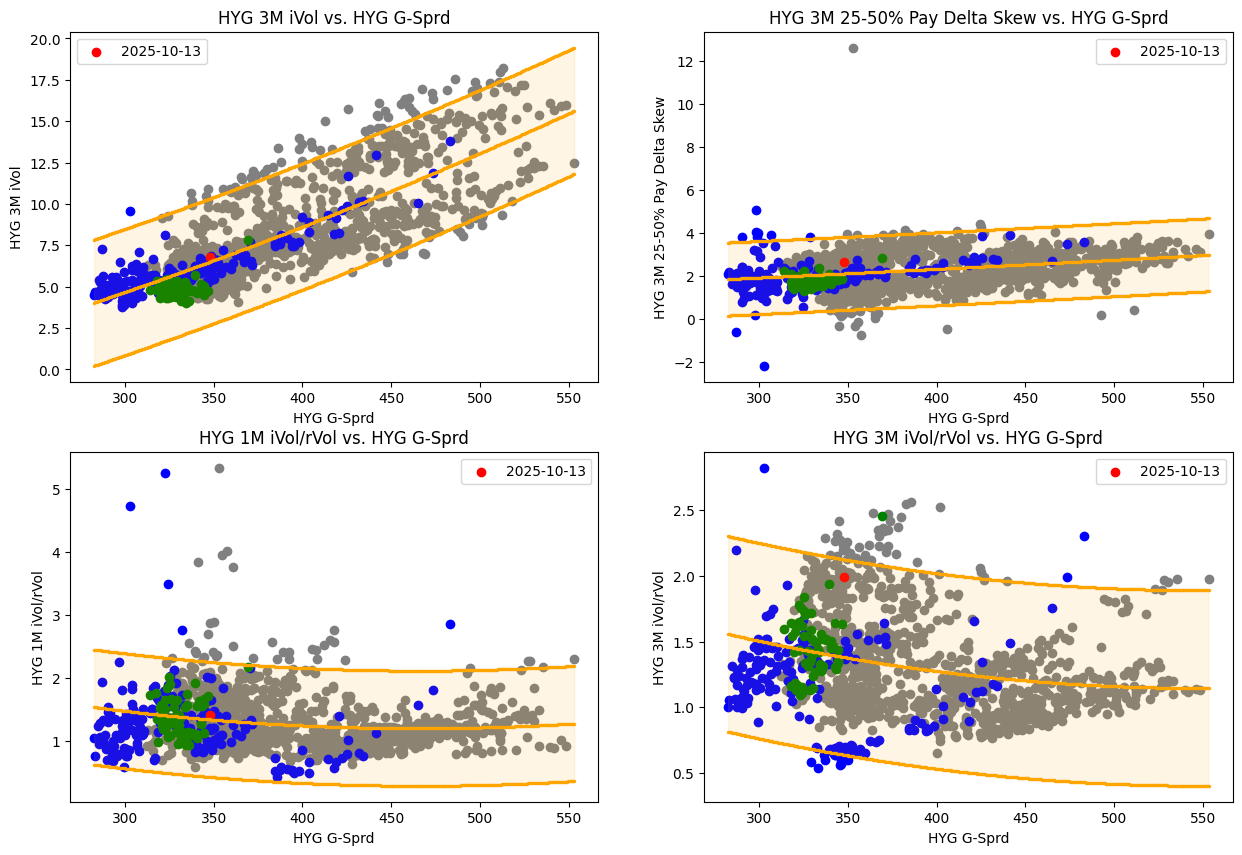

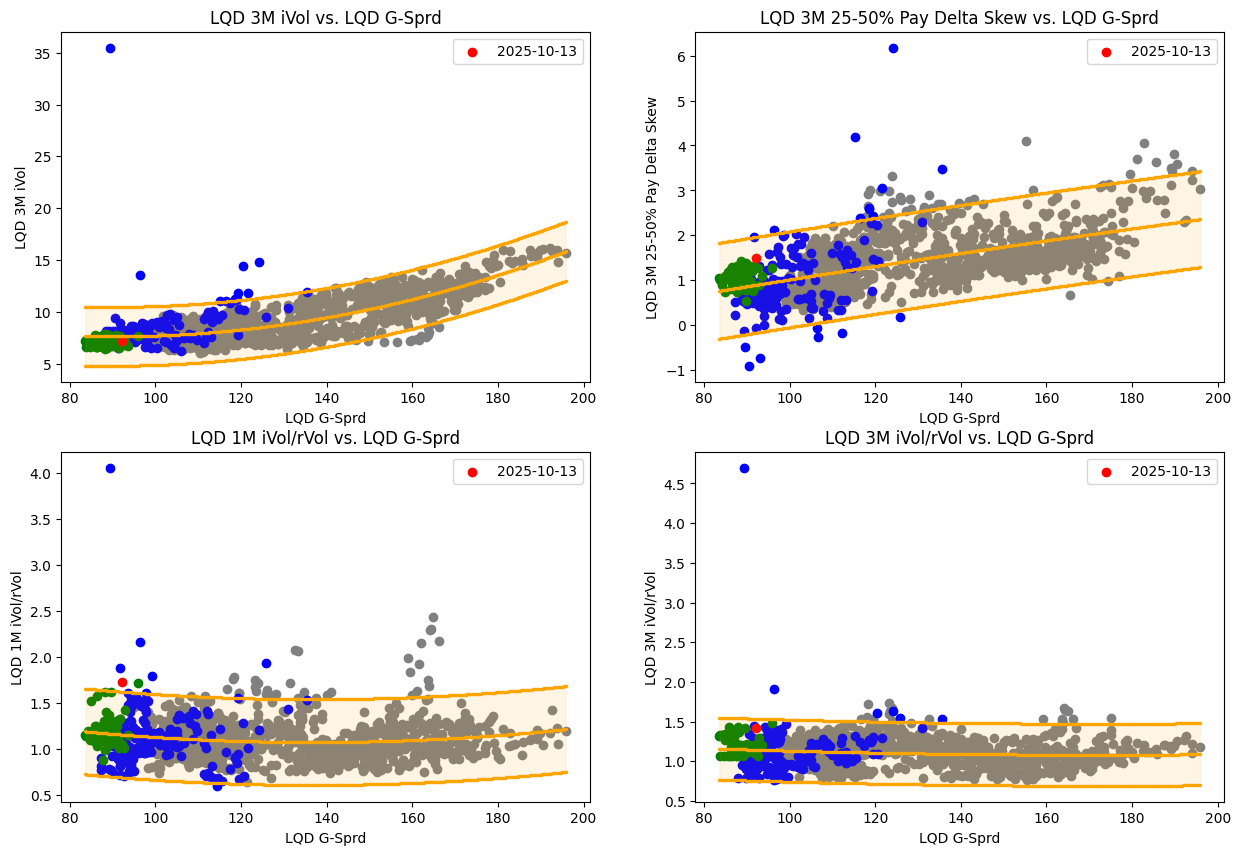

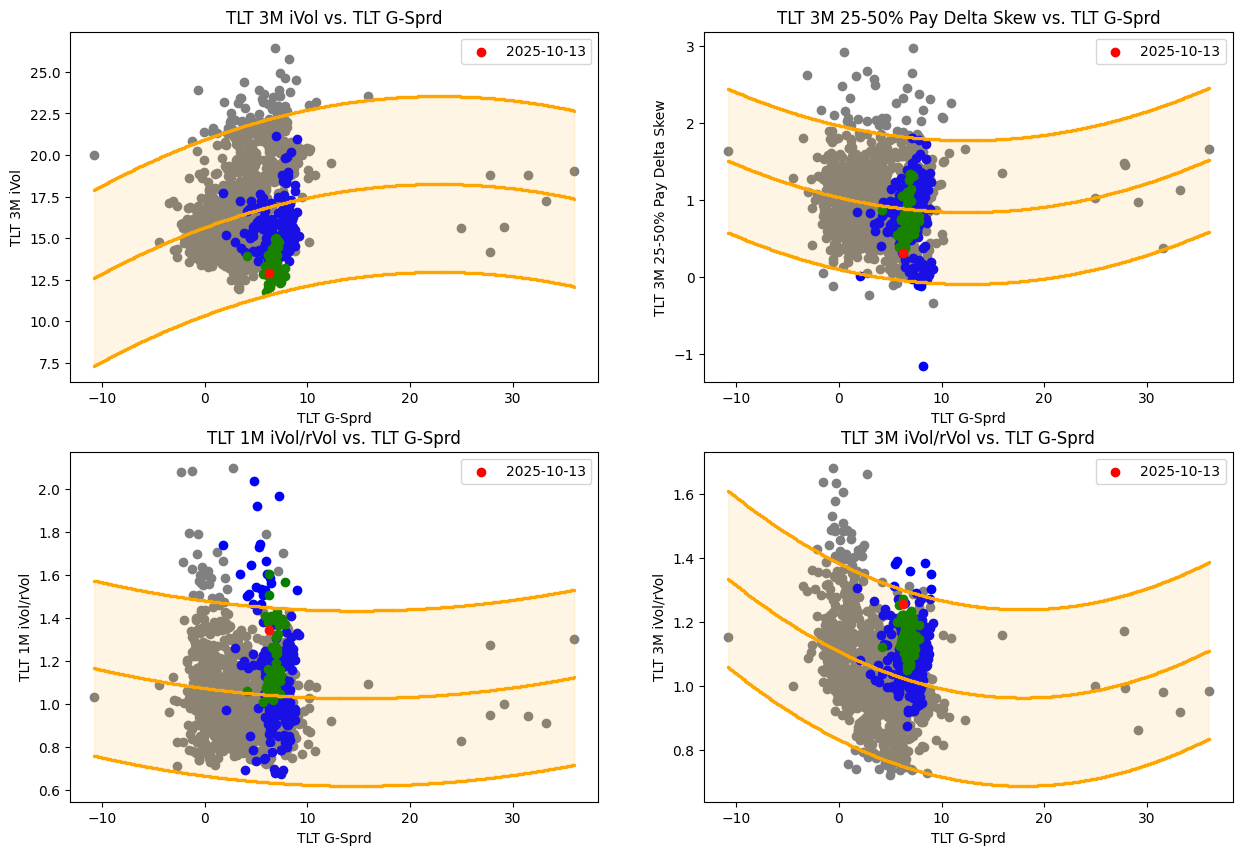

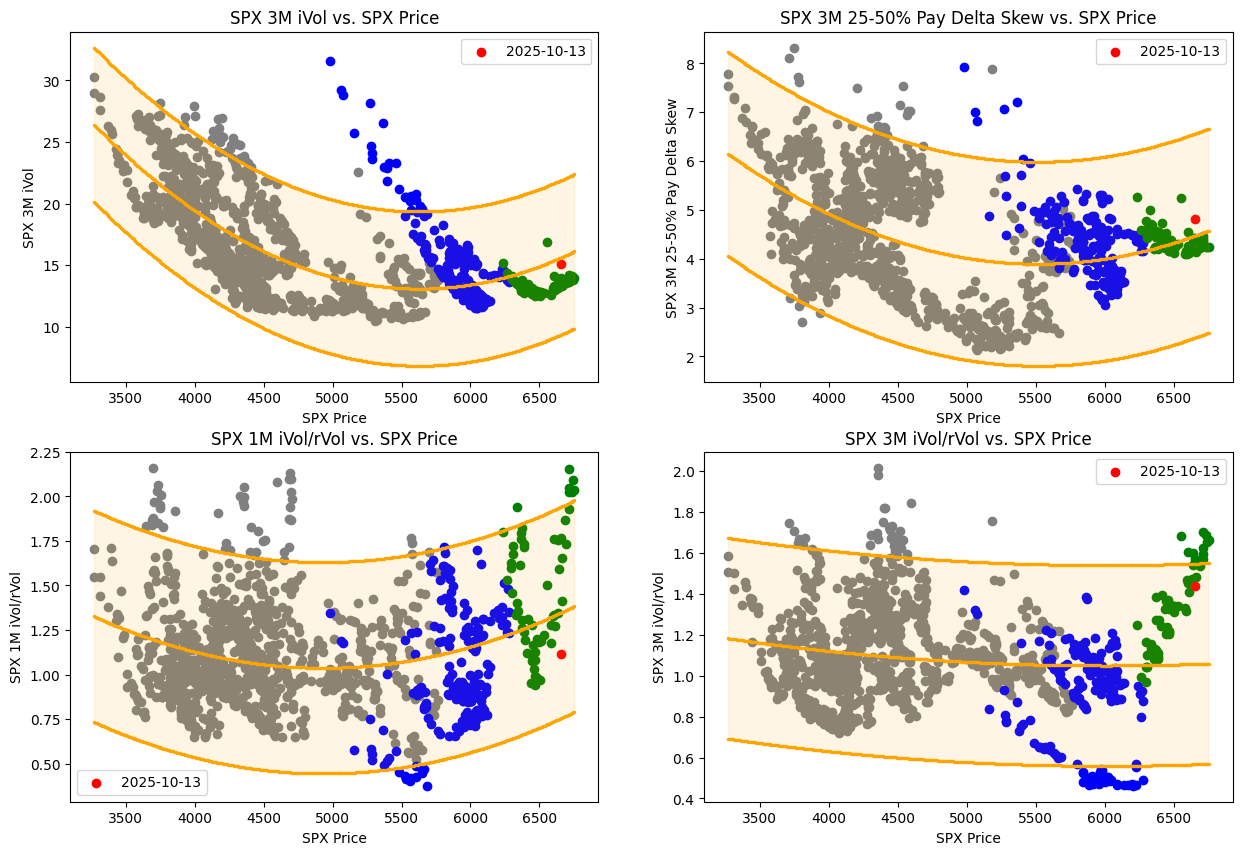

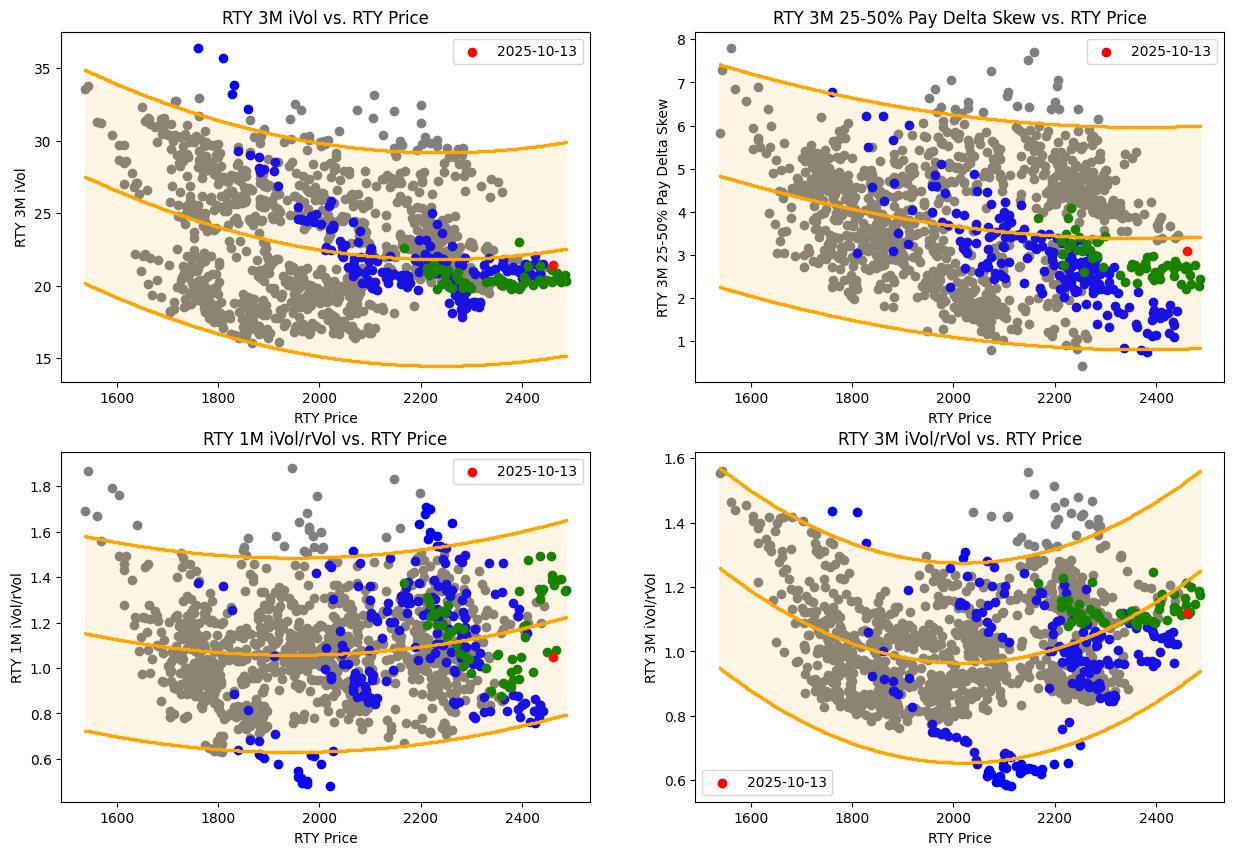

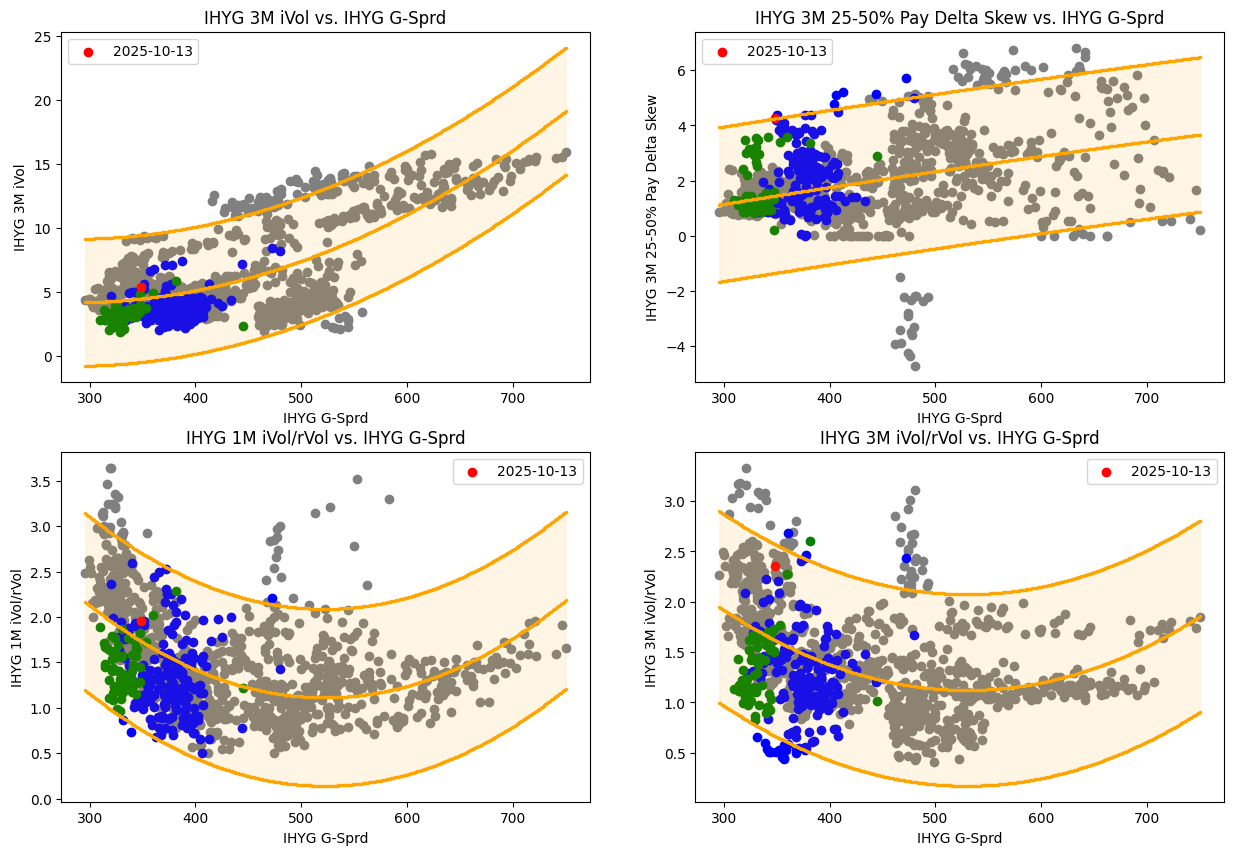

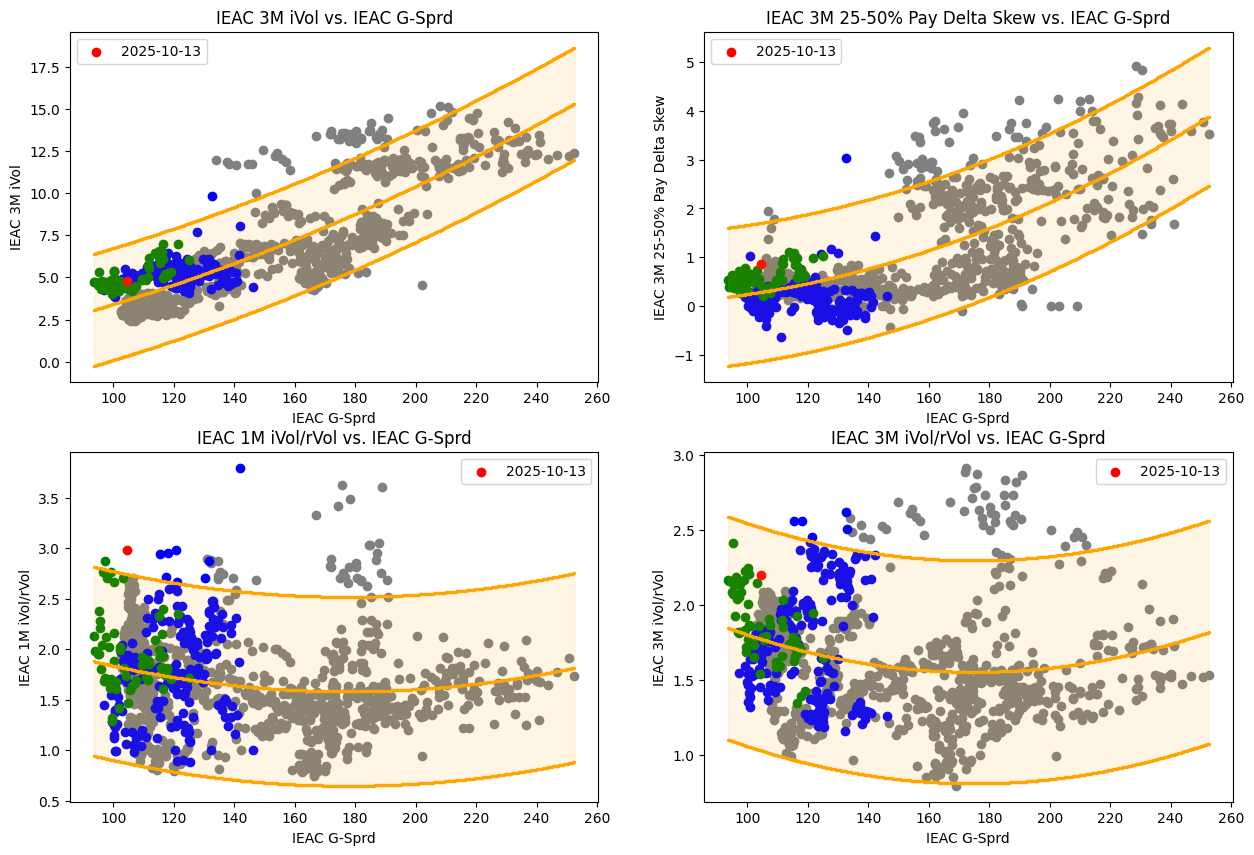

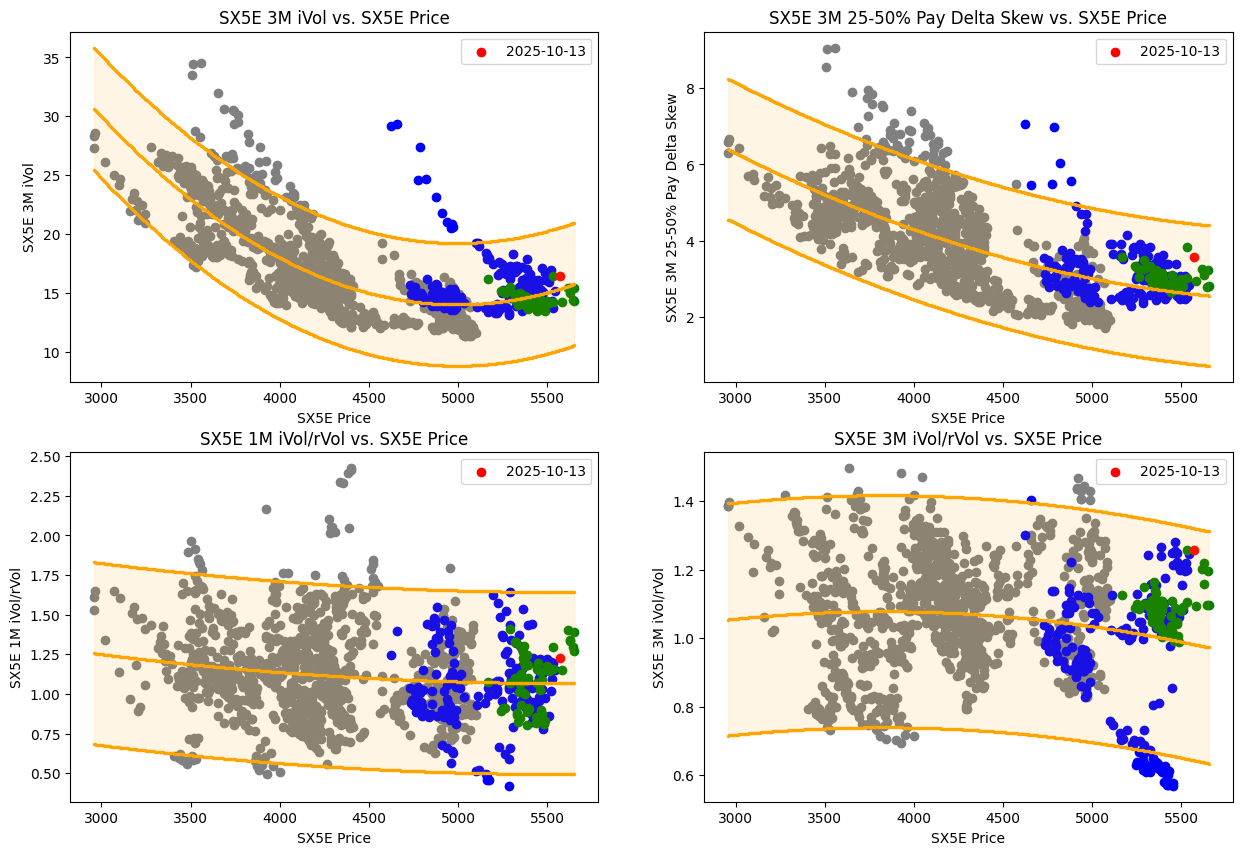

In [9]:
names_list2 = ["CDX HY 5Y","CDX IG 5Y","HYG","LQD","TLT", "SPX", "RTY", 'ITRX Main 5Y',\
              'ITRX Xover 5Y', 'ITRX SNRFIN 5Y', 'IHYG','IEAC','SX5E']

plot_num = 0
for item in names_list2:
    
    last_ivol = round(df1[f"{item} 3M iVol"].dropna().iloc[-1],2)
    last_rvol = round(df1[f"{item} 3M rVol"].dropna().iloc[-1],2)
    last_10sma_vol_ratio = round(df1[f"{item} 3M iVol/rVol (10 SMA)"].dropna().iloc[-1],2)
    last_vol_ratio = round(df1[f"{item} 3M iVol/rVol"].dropna().iloc[-1],2)
    last_10sma_skew_norm = round(df1[f"{item} 3M 25-50% pay delta skew (normalized; 10 SMA)"].dropna().iloc[-1],2)
    last_10sma_skew = round(df1[f"{item} 3M 25-50% pay delta skew (10 SMA)"].dropna().iloc[-1],2)

    for name in bbg.columns:
        if name.startswith(item):
            scatter_df = pd.concat([df1[f"{item} 3M iVol"], bbg[name]],axis=1).sort_index().dropna().copy()
            scatter_df1 = pd.concat([df1[f"{item} 3M 25-50% pay delta skew"], bbg[name]],axis=1).sort_index().dropna().copy()
            scatter_df2 = pd.concat([df1[f"{item} 1M iVol/rVol"], bbg[name]],axis=1).sort_index().dropna().copy()
            scatter_df3 = pd.concat([df1[f"{item} 3M iVol/rVol"], bbg[name]],axis=1).sort_index().dropna().copy()
            
            fig, axs = plt.subplots(2, 2, figsize=(15,10))
            
            axs[0,0].scatter(scatter_df[name].iloc[:-252], scatter_df[f"{item} 3M iVol"].iloc[:-252], color="gray")
            axs[0,0].scatter(scatter_df[name].iloc[-252:-63], scatter_df[f"{item} 3M iVol"].iloc[-252:-63], color="blue")
            axs[0,0].scatter(scatter_df[name].iloc[-63:-1], scatter_df[f"{item} 3M iVol"].iloc[-63:-1], color="green")
            axs[0,0].scatter(scatter_df[name].iloc[-1:], scatter_df[f"{item} 3M iVol"].iloc[-1:], color="red",\
                           label=f"{str(scatter_df.index[-1].date())}")

            x_scatter = pd.to_numeric(scatter_df[name], errors='coerce')
            y_scatter = pd.to_numeric(scatter_df[f"{item} 3M iVol"], errors='coerce')
            x_poly, y_poly, conf_upper, conf_lower = plot_funct(x_scatter, y_scatter)
            
            axs[0,0].scatter(x_poly, y_poly,color="orange",s=2)
            axs[0,0].scatter(x_poly, conf_upper,color="orange",s=2)
            axs[0,0].scatter(x_poly, conf_lower,color="orange",s=2)
            axs[0,0].fill_between(x_poly, conf_lower, conf_upper, color="orange", alpha=0.1)
            
            axs[0,0].set_ylabel(f"{item} 3M iVol")
            axs[0,0].set_xlabel(f"{name}")
            axs[0,0].set_title(f"{item} 3M iVol vs. {name}")
            axs[0,0].legend()

###################################################################################################
            
            axs[0,1].scatter(scatter_df1[name].iloc[:-252], scatter_df1[f"{item} 3M 25-50% pay delta skew"].iloc[:-252], color="gray")
            axs[0,1].scatter(scatter_df1[name].iloc[-252:-63], scatter_df1[f"{item} 3M 25-50% pay delta skew"].iloc[-252:-63], color="blue")
            axs[0,1].scatter(scatter_df1[name].iloc[-63:-1], scatter_df1[f"{item} 3M 25-50% pay delta skew"].iloc[-63:-1], color="green")
            axs[0,1].scatter(scatter_df1[name].iloc[-1:], scatter_df1[f"{item} 3M 25-50% pay delta skew"].iloc[-1:],\
                           color="red", label=f"{str(scatter_df1.index[-1].date())}")
            
            x_scatter = pd.to_numeric(scatter_df1[name], errors='coerce')
            y_scatter = pd.to_numeric(scatter_df1[f"{item} 3M 25-50% pay delta skew"], errors='coerce')
            x_poly, y_poly, conf_upper, conf_lower = plot_funct(x_scatter, y_scatter)
            
            axs[0,1].scatter(x_poly, y_poly,color="orange",s=2)
            axs[0,1].scatter(x_poly, conf_upper,color="orange",s=2)
            axs[0,1].scatter(x_poly, conf_lower,color="orange",s=2)
            axs[0,1].fill_between(x_poly, conf_lower, conf_upper, color="orange", alpha=0.1)
            
            axs[0,1].set_ylabel(f"{item} 3M 25-50% Pay Delta Skew")
            axs[0,1].set_xlabel(f"{name}")
            axs[0,1].set_title(f"{item} 3M 25-50% Pay Delta Skew vs. {name}")
            axs[0,1].legend()
            
###################################################################################################
            
            axs[1,0].scatter(scatter_df2[name].iloc[:-252], scatter_df2[f"{item} 1M iVol/rVol"].iloc[:-252], color="gray")
            axs[1,0].scatter(scatter_df2[name].iloc[-252:-63], scatter_df2[f"{item} 1M iVol/rVol"].iloc[-252:-63], color="blue")
            axs[1,0].scatter(scatter_df2[name].iloc[-63:-1], scatter_df2[f"{item} 1M iVol/rVol"].iloc[-63:-1], color="green")
            axs[1,0].scatter(scatter_df2[name].iloc[-1:], scatter_df2[f"{item} 1M iVol/rVol"].iloc[-1:],\
                           color="red", label=f"{str(scatter_df2.index[-1].date())}")
            
            x_scatter = pd.to_numeric(scatter_df2[name], errors='coerce')
            y_scatter = pd.to_numeric(scatter_df2[f"{item} 1M iVol/rVol"], errors='coerce')
            x_poly, y_poly, conf_upper, conf_lower = plot_funct(x_scatter, y_scatter)
            
            axs[1,0].scatter(x_poly, y_poly,color="orange",s=2)
            axs[1,0].scatter(x_poly, conf_upper,color="orange",s=2)
            axs[1,0].scatter(x_poly, conf_lower,color="orange",s=2)
            axs[1,0].fill_between(x_poly, conf_lower, conf_upper, color="orange", alpha=0.1)
            
            axs[1,0].set_ylabel(f"{item} 1M iVol/rVol")
            axs[1,0].set_xlabel(f"{name}")
            axs[1,0].set_title(f"{item} 1M iVol/rVol vs. {name}")
            axs[1,0].legend()

###################################################################################################

            axs[1,1].scatter(scatter_df3[name].iloc[:-252], scatter_df3[f"{item} 3M iVol/rVol"].iloc[:-252], color="gray")
            axs[1,1].scatter(scatter_df3[name].iloc[-252:-63], scatter_df3[f"{item} 3M iVol/rVol"].iloc[-252:-63], color="blue")
            axs[1,1].scatter(scatter_df3[name].iloc[-63:-1], scatter_df3[f"{item} 3M iVol/rVol"].iloc[-63:-1], color="green")
            axs[1,1].scatter(scatter_df3[name].iloc[-1:], scatter_df3[f"{item} 3M iVol/rVol"].iloc[-1:],\
                           color="red", label=f"{str(scatter_df3.index[-1].date())}")
            
            x_scatter = pd.to_numeric(scatter_df3[name], errors='coerce')
            y_scatter = pd.to_numeric(scatter_df3[f"{item} 3M iVol/rVol"], errors='coerce')
            x_poly, y_poly, conf_upper, conf_lower = plot_funct(x_scatter, y_scatter)
            
            axs[1,1].scatter(x_poly, y_poly,color="orange",s=2)
            axs[1,1].scatter(x_poly, conf_upper,color="orange",s=2)
            axs[1,1].scatter(x_poly, conf_lower,color="orange",s=2)
            axs[1,1].fill_between(x_poly, conf_lower, conf_upper, color="orange", alpha=0.1)
            
            axs[1,1].set_ylabel(f"{item} 3M iVol/rVol")
            axs[1,1].set_xlabel(f"{name}")
            axs[1,1].set_title(f"{item} 3M iVol/rVol vs. {name}")
            axs[1,1].legend()
            
            plt.savefig(f"Plots/VolPremium2_{plot_num}.png")
            plot_num += 1
            plt.show()

In [10]:
import os
import win32com.client

names_list2 = ["CDX HY 5Y","CDX IG 5Y","HYG","LQD","TLT", "SPX","RTY", 'ITRX Main 5Y',\
              'ITRX Xover 5Y', 'ITRX SNRFIN 5Y', 'IHYG','IEAC','SX5E']

folder_path = r'J:\All Data\56. Vol Daily Emails\Plots'

images = [f for f in os.listdir(folder_path) if f.endswith('.png')]
vp = [item for item in images if item.startswith("VolPremium_")]
vp = sorted(vp, key=lambda item: int(item.split("_")[1].rsplit(".")[0]))

vp2 = [item for item in images if item.startswith("VolPremium2_")]
vp2 = sorted(vp2, key=lambda item: int(item.split("_")[1].rsplit(".")[0]))

vs = [item for item in images if item.startswith("VolSkew_")]
vs = sorted(vs, key=lambda item: int(item.split("_")[1].split(".")[0]))

outlook = win32com.client.Dispatch("Outlook.Application")
mail = outlook.CreateItem(0)

html_body = '<html><body>'

for j, image in enumerate(vp):
    file_path = os.path.join(folder_path, image)
    if os.path.exists(file_path):
        cid = f'image{j}'
        attachment = mail.Attachments.Add(Source=file_path)
        attachment.PropertyAccessor.SetProperty("http://schemas.microsoft.com/mapi/proptag/0x3712001F", cid)
        html_body += f'<br><br><img src="cid:{cid}"><br>'
    else:
        print(f"File {file_path} not found")

for j, image in enumerate(vp2):
    file_path = os.path.join(folder_path, image)
    if os.path.exists(file_path):
        cid = f'image{j}_2'
        attachment = mail.Attachments.Add(Source=file_path)
        attachment.PropertyAccessor.SetProperty("http://schemas.microsoft.com/mapi/proptag/0x3712001F", cid)
        html_body += f'<br><br><img src="cid:{cid}"><br>'
    else:
        print(f"File {file_path} not found")

html_body += '</body></html>'
mail.HTMLBody = html_body



mail.Subject = 'Vol. Premium (auto)'
mail.CC = 'vasu.sharma@iiicm.com'
if email_both:
    mail.To = 'spyros.michas@iiicm.com'
if send_email:
    mail.Send()
    print("Vol Premium Email sent successfully")

##############################################################
outlook = win32com.client.Dispatch("Outlook.Application")
mail = outlook.CreateItem(0)

html_body = '<html><body>'

for j, image in enumerate(vs):
    file_path = os.path.join(folder_path, image)
    if os.path.exists(file_path):
        cid = f'image{j}'
        attachment = mail.Attachments.Add(Source=file_path)
        attachment.PropertyAccessor.SetProperty("http://schemas.microsoft.com/mapi/proptag/0x3712001F", cid)
        html_body += f'<br><br><img src="cid:{cid}"><br>'
    else:
        print(f"File {file_path} not found")

html_body += '</body></html>'
mail.HTMLBody = html_body

mail.Subject = 'Vol. Skew (auto)'
mail.CC = 'vasu.sharma@iiicm.com'
if email_both:
    mail.To = 'spyros.michas@iiicm.com'
if send_email:
    mail.Send()
    print("Vol Skew Email sent successfully")

Vol Premium Email sent successfully
Vol Skew Email sent successfully


Vol Skew Email sent successfully
